# Consolidating Soil Texture: from GEOS LSM to CRTM-ready files
In this Notebook we read the 30 arcsec tiles with soil properties and create a file with fractions

- clay
- sand
- silt
- organics

From which we derived these CRTM specific soil types:

```
   ! Valid type indices for the microwave land emissivity model
   ! ...The soil types
   INTEGER, PARAMETER :: N_VALID_SOIL_TYPES = 8
   INTEGER, PARAMETER :: INVALID_SOIL    =  0
   INTEGER, PARAMETER :: COARSE          =  1
   INTEGER, PARAMETER :: MEDIUM          =  2
   INTEGER, PARAMETER :: FINE            =  3
   INTEGER, PARAMETER :: COARSE_MEDIUM   =  4
   INTEGER, PARAMETER :: COARSE_FINE     =  5
   INTEGER, PARAMETER :: MEDIUM_FINE     =  6
   INTEGER, PARAMETER :: COARSE_MED_FINE =  7
   INTEGER, PARAMETER :: ORGANIC         =  8
```

The procedure for pre-processing the GEOS soil texture files follows notes provided by Rolf Reicle by email:

```
Hi Arlindo,

Here are the sand/clay fraction data that I mentioned during our conversation:

/discover/nobackup/projects/gmao/bcs_shared/make_bcs_inputs/land/soil/SOIL-DATA/soil_properties/v3/

The data are in nc4 format.  There are 452 files, each containing a 10-deg by 10-deg chunk of the globe.  (Full global coverage would be 18 x 36 = 648 files, but the "missing" files do not contain land, where land is defined as non-glaciated as usual in GEOS.)

The data are on a regular, 30-arcsec lat/lon grid.

The fields of interest for CRTM are:
Clay0-30: clay fraction 
Sand0-30: sand fraction 
OC0-30: organic carbon (OC) fraction

The "0-30" part of the variable name implies that the data are for the "top" (0-30 cm) soil layer.   There are also data for 30-100 cm, which cannot possibly matter for CRTM.

Units are percent or [0-1], not entirely sure because there's a built-in scale fac of 0.01 (but should be obvious when you read the numbers).  I'll assume [0-1] fractions in the following.

The mineral fractions should add up to 1, that is:
Silt0-30 = 1.0 - Clay0-30 - Sand0-30

The challenge is to map these soil texture fractions (sand, silt, clay) into the "coarse", "medium" and "fine" categories of CRTM. 

The OC fraction is separate.  I never quite know if this is in volumetric or mass fraction.  Finding this out will require some digging.  If I recall correctly, we use a factor of 1.72 (or 1/1.72) to convert the units between per vol and per mass.

The "Mask" variable probably contains some information about the provenance of the data (Mask:Sources = "Ice(20) Lakes(19) Holes(9) Extrapolated(8) AFSIS(3) STATSGO2(2) HWSDv1.21(1) Ocean(0)").  I think you can ignore this for now, unless this step of our processing still has holes, in which case we would need to talk.

The data in this format are used as inputs to "make_bcs", the GEOS utility that creates the bcs for a given model resolution / tile space.  This is why the files are in the sub-dir ./make_bcs_inputs/.  The original (source) files are in the sub-dir ./preprocessing_bcs_inputs/, but those are almost certainly not useful to you because the nc4 files represent a merger of various data source and (hopefully) some filling. 

If you have any questions re. the bcs, Biljana (cc'd) should be able to help.  In fact, she is currently working on updating the data from v1.21 to v2 of the primary source (HWSD).  But this update isn't ready and will likely take us at least a few more weeks (realistically, months), so it makes most sense for you to start with the above data. 

I hope this helps, Rolf

PS: The data in the ./v3 sub-dir are nearly identical to those in ./v2.  The only diff is a highly localized bug fix in Argentina, see the "readme" file in the ./v3 dir.

```

## Ingesting original GEOS tile files

In [1]:
import numpy  as np
import xarray as xr

from glob import glob

import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def fix_ds(ds):
    """
    The soil property datasets are not CF compliant and need special handling.
    Main defects:
    - unconventional attributes
    - 180 and -180 are repeaded in separate files.
    - logitude latitude are not properly annotate as coordinate variables
    """

    # Fix coordinate variables
    # ------------------------
    ds = ds.rename( { 'N_lat':'lat', 
                      'N_lon':'lon', 
                     'longitude':'lon', 
                     'latitude':'lat' })
    ds = ds.assign_coords( lon=ds.lon, lat=ds.lat)

    # Fix scaling and bad attributes, save all as float32
    ds_ = xr.Dataset()   # clean slate
    ds_ = ds_.assign_coords(lon=ds.lon, lat=ds.lat)
    for v in ds.data_vars:

        da = ds.data_vars[v]
        
        UNDEF = da.attrs['UNDEF']
        scale = da.attrs['ScaleFactor']

        if da.name == u'Mask':
            x = da.values//100  # so that it matches the "Sources" below.
            attrs = dict ( units='', 
                           missing_value=UNDEF, 
                           DigitsLtoR = 'SubOC TopOC SubMC TopMC',
                           Sources = 'Ice(20) Lakes(19) Holes(9) Extrapolated(8) AFSIS(3) STATSGO2(2) HWSDv1.21(1) Ocean(0)',
                         )
        else:
            U = da.values==UNDEF  # undef values
            x = da.values.astype('float32') # all are floats now
            x[U]  = np.nan
            x[~U] = scale * x[~U]
            attrs = dict ( units=da.attrs['units'], missing_value=np.nan )

        da = xr.DataArray(x, dims=['lat','lon'], attrs=attrs)

        ds_[v] = da    
    
    return ds_


In [3]:
soil_dn = '/discover/nobackup/projects/gmao/aist-nr/data/soil_properties/tiles'
DS = []  # list with tile datasets
lon_min, lon_max, lat_min, lat_max = (180,-180,90,-90)
delta = 30 / 3600. # convert 30 arcsec to degrees
tol = delta
debug = True
tile180W, tile180E = ([], [])

for tn in glob(soil_dn+'/*.nc'):

    tile = tn.split('.')[0][-6:]

    #print('[] Working on tile', tile)
    
    ds = fix_ds(xr.open_dataset(tn))
    DS += [ds,]
    lon, lat = ds.lon.values, ds.lat.values
    lon_min = min(lon_min, lon.min())
    lon_max = max(lon_max, lon.max())
    lat_min = min(lat_min, lat.min())
    lat_max = max(lat_max, lat.max())

    if debug: 
            
        if abs(lon[-1]-180)<tol:
            mark = '+++'
            print('Tile %s Longitude range: [%7.2f, %7.2f]'%(tile,lon[0],lon[-1]),mark)
            print('Tile %s Latitude  range: [%7.2f, %7.2f]'%(tile,lat[0],lat[-1]))
            tile180E.append(tile)
        elif abs(lon[0]+180)<tol:
            mark = '---'
            print('Tile %s Longitude range: [%7.2f, %7.2f]'%(tile,lon[0],lon[-1]),mark)
            print('Tile %s Latitude  range: [%7.2f, %7.2f]'%(tile,lat[0],lat[-1]))
            tile180W.append(tile)
        else:
            mark = ''
            
        #print('Tile %s Longitude range: [%7.2f, %7.2f]'%(tile,lon[0],lon[-1]),mark)
        #print('Tile %s Latitude  range: [%7.2f, %7.2f]'%(tile,lat[0],lat[-1]))

print('Global Longitude range, delta: [%7.2f, %7.2f, %7.4f]'%(lon_min,lon_max,lon[1]-lon[0]))
print('Global Latitude  range, delta: [%7.2f, %7.2f, %7.4f]'%(lat_min,lat_max,lat[1]-lat[0]))

DS[0]


Tile H01V08 Longitude range: [-180.00, -170.00] ---
Tile H01V08 Latitude  range: [ -20.00,  -10.00]
Tile H01V05 Longitude range: [-180.00, -170.00] ---
Tile H01V05 Latitude  range: [ -50.00,  -40.00]
Tile H36V06 Longitude range: [ 170.00,  180.00] +++
Tile H36V06 Latitude  range: [ -40.00,  -30.00]
Tile H01V01 Longitude range: [-180.00, -170.00] ---
Tile H01V01 Latitude  range: [ -90.00,  -80.00]
Tile H01V07 Longitude range: [-180.00, -170.00] ---
Tile H01V07 Latitude  range: [ -30.00,  -20.00]
Tile H36V17 Longitude range: [ 170.00,  180.00] +++
Tile H36V17 Latitude  range: [  70.00,   80.00]
Tile H01V17 Longitude range: [-180.00, -170.00] ---
Tile H01V17 Latitude  range: [  70.00,   80.00]
Tile H36V08 Longitude range: [ 170.00,  180.00] +++
Tile H36V08 Latitude  range: [ -20.00,  -10.00]
Tile H36V01 Longitude range: [ 170.00,  180.00] +++
Tile H36V01 Latitude  range: [ -90.00,  -80.00]
Tile H01V02 Longitude range: [-180.00, -170.00] ---
Tile H01V02 Latitude  range: [ -80.00,  -70.00]


<xarray.Dataset> Size: 43MB
Dimensions:     (lon: 1200, lat: 1200)
Coordinates:
  * lon         (lon) float32 5kB -140.0 -140.0 -140.0 ... -130.0 -130.0 -130.0
  * lat         (lat) float32 5kB -9.996 -9.987 -9.979 ... -0.0125 -0.004158
Data variables:
    Clay0_30    (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Clay30_100  (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Gravel      (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Mask        (lat, lon) int16 3MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    OC0_30      (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    OC30_100    (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Sand0_30    (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Sand30_100  (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan

## Examine 180W and 180E Values for consistency

In [4]:
dsw = fix_ds(xr.open_dataset(soil_dn+'/SoilProperties_H36V17.nc'))
dse = fix_ds(xr.open_dataset(soil_dn+'/SoilProperties_H01V17.nc'))

fracw = 1 - (dsw.Clay0_30 + dsw.Sand0_30)
frace = 1 - (dse.Clay0_30 + dse.Sand0_30)

diff = fracw[:,0]-frace[:,-1]

print('Fraction West:', fracw.values.min(), fracw.values.max())
print('Fraction East:', frace.values.min(), frace.values.max())
print('   Difference:', diff.values.min(), diff.values.max())

dsw

Fraction West: nan nan
Fraction East: nan nan
   Difference: nan nan


<xarray.Dataset> Size: 43MB
Dimensions:     (lon: 1200, lat: 1200)
Coordinates:
  * lon         (lon) float32 5kB 170.0 170.0 170.0 170.0 ... 180.0 180.0 180.0
  * lat         (lat) float32 5kB 70.0 70.01 70.02 70.03 ... 79.98 79.99 80.0
Data variables:
    Clay0_30    (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Clay30_100  (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Gravel      (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Mask        (lat, lon) int16 3MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    OC0_30      (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    OC30_100    (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Sand0_30    (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan
    Sand30_100  (lat, lon) float32 6MB nan nan nan nan nan ... nan nan nan nan

/home/adasilva/.conda/envs/xesmf_env/lib/python3.11/site-packages/matplotlib/axes/_axes.py:6831: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/adasilva/.conda/envs/xesmf_env/lib/python3.11/site-packages/matplotlib/axes/_axes.py:6832: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


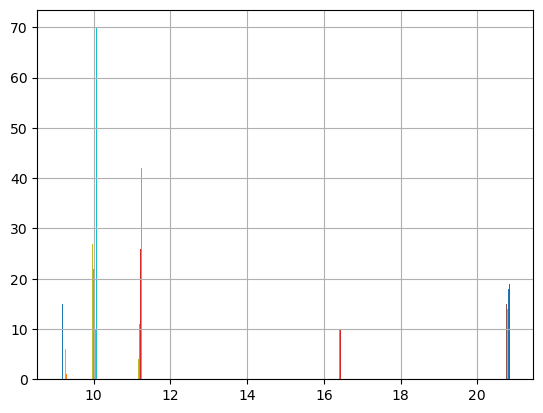

In [5]:
plt.hist(dsw.Clay0_30.values)
plt.grid()

# Global Dataset with Soil Fractions
Let's start by creating arrays with the global data. Assume a standard GEOS lat/lon grid

- Longitude: [-180,180)
- Latitude:  [-90,90]


In [6]:
nlon, nlat = ( (360//30) * 3600, 1 + (180//30) * 3600 )
print('nlon =', nlon, '   nlat =', nlat)
                                       
lon = np.linspace(-180., 180., nlon, endpoint=False )
lat  = np.linspace( -90.,  90., nlat, endpoint=True )

print('Longitude range: [%7.2f, %7.2f]'%(lon[0],lon[-1]))
print('Latitude  range: [%7.2f, %7.2f]'%(lat[0],lat[-1]))

nlon = 43200    nlat = 21601
Longitude range: [-180.00,  179.99]
Latitude  range: [ -90.00,   90.00]


### Global Xarray Dataset

In [7]:
gds = xr.Dataset()
Lon = xr.DataArray(lon, dims=['lon'], attrs={'units':'degrees_east'})
Lat = xr.DataArray(lat, dims=['lat'], attrs={'units':'degrees_north'})
gds = gds.assign_coords(lon=Lon,lat=Lat)
gds = gds.assign_attrs(title='GEOS LSM Soil Texture', 
                       conventions='CF', 
                       institution='Global Modeling and Assimilation Office, NASA/GSFC',
                       source='Tile files written by Sarith Mahanama for the GEOS LSM',
                       history='A. da Silva created this CF compliant global file',
                       contact='arlindo.m.dasilva@nasa.gov',
                       )
gds

<xarray.Dataset> Size: 518kB
Dimensions:  (lon: 43200, lat: 21601)
Coordinates:
  * lon      (lon) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat      (lat) float64 173kB -90.0 -89.99 -89.98 -89.97 ... 89.98 89.99 90.0
Data variables:
    *empty*
Attributes:
    title:        GEOS LSM Soil Texture
    conventions:  CF
    institution:  Global Modeling and Assimilation Office, NASA/GSFC
    source:       Tile files written by Sarith Mahanama for the GEOS LSM
    history:      A. da Silva created this CF compliant global file
    contact:      arlindo.m.dasilva@nasa.gov

In [8]:
def global_var(v, nlat, nlon, delta, DS):
    """
    Concatenate tiles into a global array for variable v.
    Notice that longitude +180 is not included in the global array.
    """

    # Global array with same type as variable
    x = np.zeros((nlat,nlon)).astype(DS[0][v].values.dtype)

    for ds in DS:

        lon, lat = ds.lon.values, ds.lat.values
        i1 = int((lon[0] +180)/delta)
        i2 = int((lon[-1]+180)/delta)
        j1 = int((lat[0] +90)/delta)
        j2 = int((lat[-1]+90)/delta)

        if (i2-i1+1) != lon.size:
            print(delta,lon[1]-lon[0],i2-i1+1)
            raise ValueError('inconsistent sizes: i1, i2, lon.size = %d %d %d'%(i1,i2,lon.size))
        if (j2-j1+1) != lat.size:
            raise ValueError('inconsistent sizes: j1, j2, lat.size = %d %d %d'%(j1,j2,lat.size))
               
        # Special handle tiles with 180E longitude: lon[i] = -180 + i * lon
        if abs(lon[-1]-180)<delta:
           x[j1:j2+1,i1:i2] = ds[v][:,0:-1] # skip last longitude
        else:
           x[j1:j2+1,i1:i2+1] = ds[v][:,:]  # take the whole tile

    return x


In [9]:
# For each data variable...
ds = DS[0] # reference dataset
for v in ds.data_vars:
    print('[] Working on variable',v)
    x = global_var(v, nlat, nlon, delta, DS)  # construct global array for this var
    gds[v] = xr.DataArray(x, dims=['lat','lon'], attrs=ds[v].attrs)
gds

[] Working on variable Clay0_30
[] Working on variable Clay30_100
[] Working on variable Gravel
[] Working on variable Mask
[] Working on variable OC0_30
[] Working on variable OC30_100
[] Working on variable Sand0_30
[] Working on variable Sand30_100


<xarray.Dataset> Size: 28GB
Dimensions:     (lon: 43200, lat: 21601)
Coordinates:
  * lon         (lon) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat         (lat) float64 173kB -90.0 -89.99 -89.98 ... 89.98 89.99 90.0
Data variables:
    Clay0_30    (lat, lon) float32 4GB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    Clay30_100  (lat, lon) float32 4GB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    Gravel      (lat, lon) float32 4GB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    Mask        (lat, lon) int16 2GB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    OC0_30      (lat, lon) float32 4GB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    OC30_100    (lat, lon) float32 4GB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    Sand0_30    (lat, lon) float32 4GB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    Sand30_100  (lat, lon) float32 4GB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
Attributes:
    title:        GEOS LSM Soil Texture
    conventions:  CF
    institution:  Global Modeling and Assimilation Office, NASA/GSFC
    source:       Tile files written by Sarith Mahanama for the GEOS LSM
    history:      A. da Silva created this CF compliant global file
    contact:      arlindo.m.dasilva@nasa.gov

## Wrire Compressed and Chunked Global Dataset

In [10]:
def write_compressed_nc(ds,filename):
    """
    Write out a compressed and chunked netcdf file.
    """

    # Chunks for each dimension
    # --------------------------
    chunks = dict()
    chunks['lat'] = 1200
    chunks['lon'] = 1200

    # Create encoding for each variable
    # ---------------------------------
    encode = {}
    for v in ds.data_vars:
        
        chunksizes = [ chunks[d] for d in ds[v].dims ]
        encode[v] = {#'compression':'gzip', 'complevel':2,
                     "zlib": True, "complevel": 2,
                     'chunksizes':chunksizes}

    # Write out compressed dataset
    # ---------------------------- 
    print('[] Writing',filename)
    ds.to_netcdf(filename,engine='netcdf4',format='NETCDF4',encoding=encode)     
       

In [11]:
write_compressed_nc(gds,'geos.soil_texture.x43200_y21601.nc4')

[] Writing geos.soil_texture.x43200_y21601.nc4
